## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
# import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import string
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv

In [2]:
object_name = 'Konstytucja_prediction' #Konstytucja_indicators / Konstytucja_prediction

In [3]:
preprocessing_method = 'logarithm' # none / normalization / logarithm

book_name = 'app'

collapse = False

elements_to_keep = [
                     'Al',
                     'S',
                     'Cr',
                     'Mn',
                     'Co',
                     'Cu',
                     'Zn',
                     'Pb'
                    ]

columns_to_keep_inks = {
                        'Konstytucja_indicators' : elements_to_keep,
                        'Konstytucja_prediction' : elements_to_keep
                        }

columns_to_keep_inds = { 
                        'Konstytucja_indicators' : [el + '_inds' for el in elements_to_keep],
                        'Konstytucja_prediction' : [el + '_inds' for el in elements_to_keep]
                        }

In [4]:
data_path = {'Konstytucja_indicators' : '../data/Lipiec_2024.xlsx',
            'Konstytucja_prediction' : '../results/Konstytucja/prediction_from_model_regression_2024_09_28_23_53_51'}

figures_path = {'Konstytucja_indicators' : '../results/visualisations/Konstytucja_indicators/',
                'Konstytucja_prediction' : '../results/visualisations/Konstytucja_prediction/'
               }

ground_truth_path = {'Konstytucja_indicators' : '../data/opis.xlsx',
                    'Konstytucja_prediction' : '../data/opis.xlsx'}

## Loading the data

In [5]:
if object_name == 'Konstytucja_indicators':
    df = pd.ExcelFile(data_path[object_name])
    df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(1, 3945))
    df.columns = [x.split('.')[0]+'_inds' for x in list(df.columns)]
    df.drop(index=[0], inplace=True)
    
elif object_name == 'Konstytucja_prediction':
    inks = np.loadtxt(data_path[object_name], delimiter=',')
    df = pd.DataFrame(data=inks, columns=columns_to_keep_inks[object_name])

## Preprocessing

In [6]:
df.reset_index(drop=True, inplace=True)

In [7]:
#################################################

### Dividing to APP and ASC

In [8]:
# df_app = df.iloc[:375,:]
# df_asc = df.iloc[375:,]

# if book_name == 'app':
#     df = df_app
# elif book_name == 'asc':
#     df = df_asc

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [9]:
if object_name == 'Konstytucja_indicators':
    df = df[columns_to_keep_inds[object_name]]
elif object_name == 'Konstytucja_prediction':
    df = df[columns_to_keep_inks[object_name]]

2. Let's check if there are any rows with missing values.

In [10]:
(df.shape[0] - df.dropna().shape[0])/df.shape[0]

0.0

### Collapsing 15 copies to one data point (optional)

In [11]:
if collapse:
    df = df.groupby(np.arange(len(df))//15).mean()

### Converting to np.array

In [12]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [13]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [14]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_3168/1324458353.py:2: RuntimeWarning: invalid value encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


## Ground truth

In [15]:
df = pd.ExcelFile(data_path['Konstytucja_indicators'])
class_df = df.parse('Arkusz1', header=0, usecols=range(31,32), skiprows=range(1, 3946))
class_df.columns = ['Code']
class_df['Code'] = class_df['Code'].apply(lambda x: x.replace('.', ''))
class_df['Code'] = class_df['Code'].apply(lambda x: x[:-1] if x.endswith(('D', 'y',)) else x)
class_df['Code'] = class_df['Code'].astype(str)

In [16]:
# class_df_app = class_df.iloc[:375,:]
# class_df_asc = class_df.iloc[375:,]

# if book_name == 'app':
#     class_df = class_df_app
# elif book_name == 'asc':
#     class_df = class_df_asc

In [17]:
class_names_dict = {'podpis - Małachowski' : 'Małachowski',
                   'podpis -Małachowski' : 'Małachowski',
                   'podpis - Kossakowski' : 'Kossakowski',
                    'podpis - Jabłonowski' : 'Jabłonowski',
                    'podpis - Szydłowski' : 'Szydłowski',
                    'podpis - Kwilecki' : 'Kwilecki',      
                    'podpis - Plater': 'Plater', 
                    'podpis - Stroynowski' : 'Stroynowski', 
                    'podpis - Potocki' : 'Potocki',
                    'podpis - Zboiński' : 'Zboiński',
                    'podpis - Nowowiejski' : 'Nowowiejski',
                    'podpis - Radzicki' : 'Radzicki',
                    'podpis - Zabiełło' : 'Zabiełło',
                    'podpis - Puttkamer' : 'Puttkamer',
                    'podpis - Sapieha' : 'Sapieha',
                    'treść' : 'treść',
                    'poprawka' : 'poprawka',
                    'poprawka ': 'poprawka',
                    'papier' : 'papier',
                    'oblatowanie' : 'oblatowanie',
                    'komentarz' : 'komentarz',
                    'plama' : 'plama'
                    }

class_names_dict = {'podpis - Małachowski' : 'Małachowski - signature',
                   'podpis -Małachowski' : 'Małachowski - signature',
                   'podpis - Kossakowski' : 'Kossakowski - signature',
                    'podpis - Jabłonowski' : 'Jabłonowski - signature',
                    'podpis - Szydłowski' : 'Szydłowski - signature',
                    'podpis - Kwilecki' : 'Kwilecki - signature',      
                    'podpis - Plater': 'Plater - signature', 
                    'podpis - Stroynowski' : 'Stroynowski - signature', 
                    'podpis - Potocki' : 'Potocki - signature',
                    'podpis - Zboiński' : 'Zboiński - signature',
                    'podpis - Nowowiejski' : 'Nowowiejski - signature',
                    'podpis - Radzicki' : 'Radzicki - signature',
                    'podpis - Zabiełło' : 'Zabiełło - signature',
                    'podpis - Puttkamer' : 'Puttkamer - signature',
                    'podpis - Sapieha' : 'Sapieha - signature',
                    'treść' : 'treść',
                    'poprawka' : 'poprawka',
                    'poprawka ': 'poprawka',
                    'papier' : 'papier',
                    'oblatowanie' : 'oblatowanie',
                    'komentarz' : 'komentarz',
                    'plama' : 'plama'
                    }

In [18]:
ground_truth_df = pd.ExcelFile(ground_truth_path[object_name])
ground_truth_df = ground_truth_df.parse('KONSTYTUCJA', header=1, usecols=range(1,5))
ground_truth_df.columns = ['Code', 'Source', 'Page', 'Class name']
ground_truth_df['Code'] = ground_truth_df['Code'].apply(lambda x: x[:-1] if x.endswith(('A', 'B', 'C')) else x)
ground_truth_df.drop(columns=['Source', 'Page'], inplace=True)
ground_truth_df['Code'] = ground_truth_df['Code'].astype(str)
ground_truth_df['Class name'] = ground_truth_df['Class name'].map(class_names_dict)
ground_truth_df.drop_duplicates(['Code'], inplace=True)

In [19]:
class_df = class_df.merge(ground_truth_df, on='Code', how='left')

In [20]:
# with pd.option_context('display.max_rows', 1000, 'display.max_columns', 10):
#     display(class_df)

### Analysis

In [21]:
if collapse:
    y = [class_df['Class name'].iloc[15*i] for i in range(int(X.shape[0]))]
    y = [str(y) for y in y]
    names_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 45, 46]
    rest_indices = (set(range(len(y)))).difference(set(names_indices))
else:
    y = class_df['Class name']
    y = [str(y) for y in y]
    names_indices = [list(range(i*15,i*15+15)) for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 45, 46]]
    names_indices = [el for l in names_indices for el in l]
    rest_indices = (set(range(len(y)))).difference(set(names_indices))

### PCA

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [22]:
%matplotlib notebook

<IPython.core.display.Javascript object>


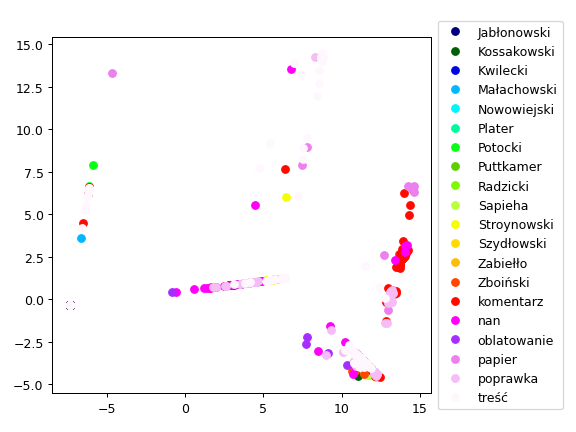

In [23]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#INDICATORS

In [ ]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#INDICATORS

In [ ]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 15

In [ ]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:3], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 15

In [ ]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION

In [ ]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION 

### tSNE

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

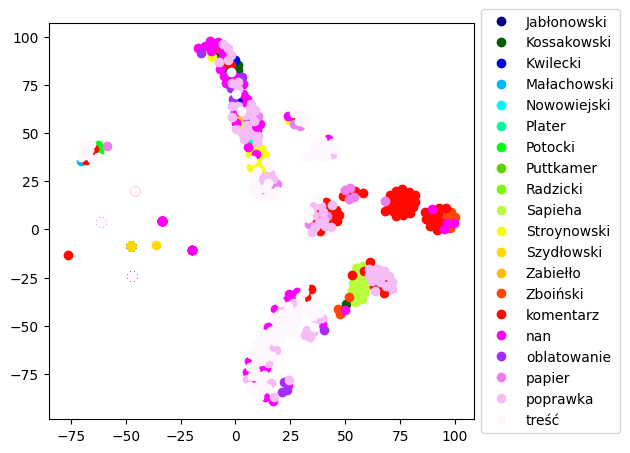

In [21]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#INDICATORS

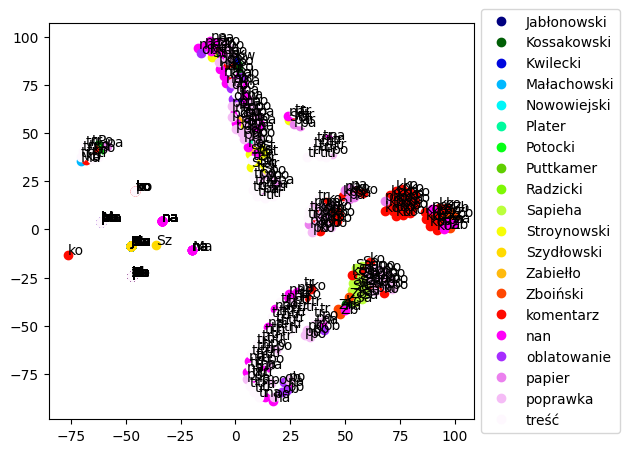

In [22]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#INDICATORS

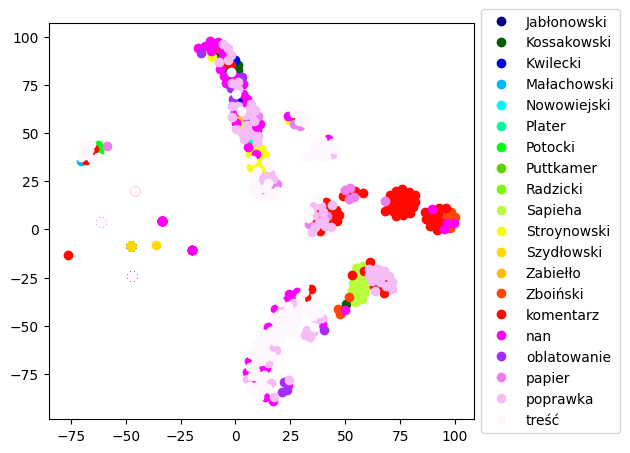

In [23]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 15

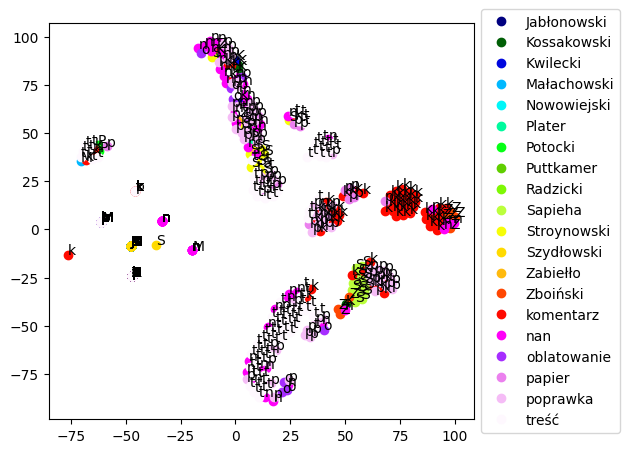

In [24]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION ALL 15

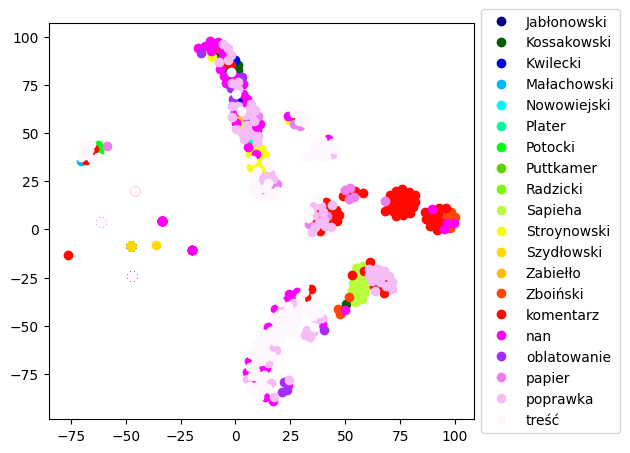

In [25]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION

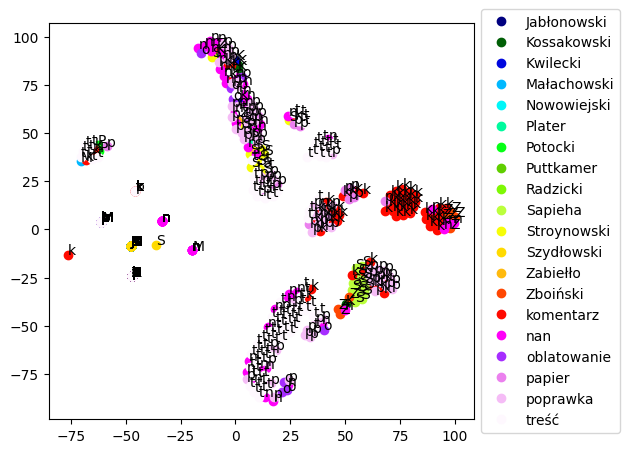

In [26]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#PREDICTION

- drawing random records from the same group?

## Clustering

In [22]:
from sklearn import cluster

In [23]:
if collapse:
    y = [class_df['Class name'].iloc[15*i] for i in range(int(X.shape[0]))]
    y = [str(y) for y in y]
else:
    y = class_df['Class name']
    y = [str(y) for y in y]

In [24]:
cluster_only_names = False
if cluster_only_names:
    X_to_cluster = X[names_indices,:]
    y_to_plot = [y[ind] for ind in names_indices]
else:
    X_to_cluster = X
    y_to_plot = y

In [25]:
nr_of_clusters = 20
clustering = cluster.AgglomerativeClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.SpectralClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.DBSCAN().fit(X_to_cluster)

#clustering.labels_

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_to_cluster)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_to_cluster)

In [27]:
%matplotlib notebook

In [28]:
clustering.labels_.shape

(795,)

In [29]:
class_df['Code']

0          APP0
1          APP0
2          APP0
3          APP0
4          APP0
         ...   
790    ASCBLANK
791    ASCBLANK
792    ASCBLANK
793    ASCBLANK
794    ASCBLANK
Name: Code, Length: 795, dtype: object

<IPython.core.display.Javascript object>


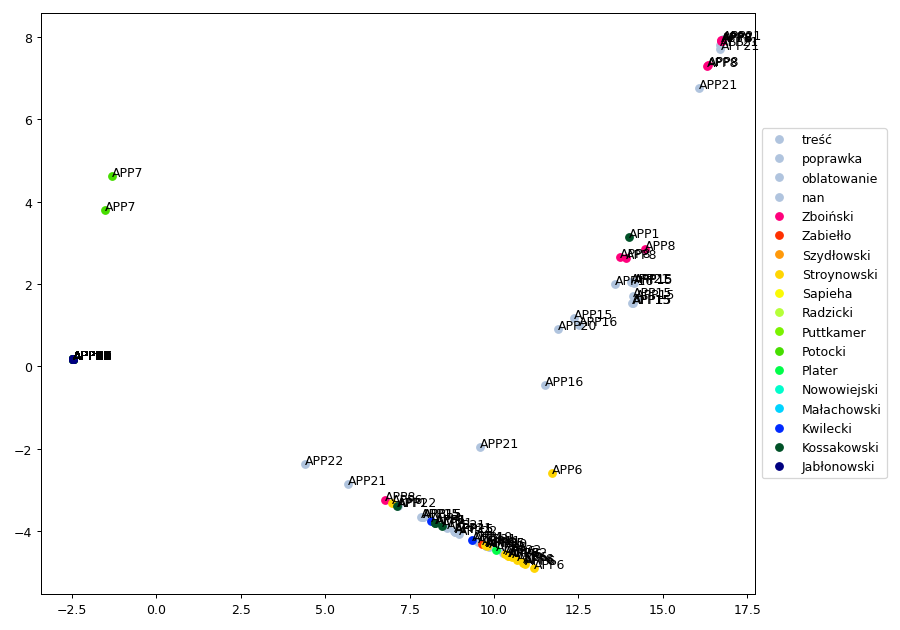

In [41]:
annotate = True

if collapse:
    color = cm.gist_ncar(np.linspace(1, 0, len(set(y_to_plot))))
else:
    color = cm.gist_ncar(np.linspace(1, 0, len(set(y_to_plot))))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color='lightsteelblue')
    else:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color=color[label_nr])
    
if annotate:
    for i in range(X_pca.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            #version with cluster numbers
            plt.annotate(clustering.labels_[i], (X_pca[i, 0], X_pca[i,1]))
            #version with book name
            #plt.annotate(class_df['Code'][i], (X_pca[i, 0], X_pca[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.tight_layout()
plt.show()

#PREDICTION ALL 15

<IPython.core.display.Javascript object>


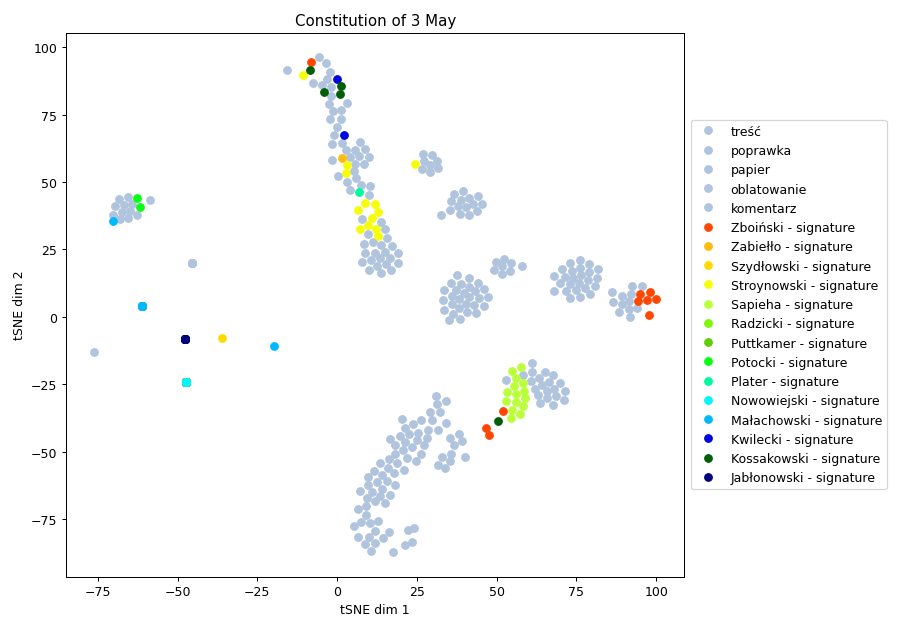

In [31]:
annotate = True

if collapse:
    color = cm.gist_ncar(np.linspace(1, 0, len(set(y_to_plot))))
else:
    color = cm.gist_ncar(np.linspace(1, 0, len(set(y_to_plot))))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color='lightsteelblue')
#     elif label in ['nan']:
#         pass
    else:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color=color[label_nr])
    
# if annotate:
#     for i in range(X_tsne.shape[0]):
#         if isinstance(y_to_plot[i], float):
#             pass
#         else:
#             plt.annotate(clustering.labels_[i], (X_tsne[i, 0], X_tsne[i,1]))
            
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.xlabel('tSNE dim 1')
plt.ylabel('tSNE dim 2')
plt.title('Constitution of 3 May')

plt.tight_layout()
plt.show()
plt.savefig('../figures/tsne.png')


#PREDICTION ALL 15

In [ ]:
clusters = []
for i in range(nr_of_clusters):
    clust = [el for el in list(zip(clustering.labels_, y_to_plot)) if el[0]==i]
    clusters.append(clust)

In [ ]:
# EUCLIDEAN
# bad: 0, 2, 7, 8
# medium: 3, 6, 9, 10, 11
# good: 1, 4, 5, 12

# COSINE
# bad: 1, 4, 5, 6, 7
# medium: 3
# good: 0, 2

clusters

In [ ]:
ms = cluster.MeanShift(banwidth=banwidth, bin_seeding=True)
two_means = cluster.MiniBatchKMeans(
    n_clusters=params["n_clusters"],
    random_state=params["random_state"],
)
ward = cluster.AgglomerativeClustering(
    n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
)
spectral = cluster.SpectralClustering(
    n_clusters=params["n_clusters"],
    eigen_solver="arpack",
    affinity="nearest_neighbors",
    random_state=params["random_state"],
)
dbscan = cluster.DBSCAN(eps=params["eps"])
hdbscan = cluster.HDBSCAN(
    min_samples=params["hdbscan_min_samples"],
    min_cluster_size=params["hdbscan_min_cluster_size"],
    allow_single_cluster=params["allow_single_cluster"],
)
optics = cluster.OPTICS(
    min_samples=params["min_samples"],
    xi=params["xi"],
    min_cluster_size=params["min_cluster_size"],
)
affinity_propagation = cluster.AffinityPropagation(
    damping=params["damping"],
    preference=params["preference"],
    random_state=params["random_state"],
)
average_linkage = cluster.AgglomerativeClustering(
    linkage="average",
    metric="cityblock",
    n_clusters=params["n_clusters"],
    connectivity=connectivity,
)
birch = cluster.Birch(n_clusters=params["n_clusters"])
gmm = mixture.GaussianMixture(
    n_components=params["n_clusters"],
    covariance_type="full",
    random_state=params["random_state"],
)

clustering_algorithms = (
    ("MiniBatch\nKMeans", two_means),
    ("Affinity\nPropagation", affinity_propagation),
    ("MeanShift", ms),
    ("Spectral\nClustering", spectral),
    ("Ward", ward),
    ("Agglomerative\nClustering", average_linkage),
    ("DBSCAN", dbscan),
    ("HDBSCAN", hdbscan),
    ("OPTICS", optics),
    ("BIRCH", birch),
    ("Gaussian\nMixture", gmm),
)